In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df = pd.read_csv("../data/processed_real_mimic_ed.csv")

print("Shape:", df.shape)
df.head()

Shape: (418094, 276)


,temperature,heartrate,resprate,o2sat,sbp,dbp,acuity,chiefcomplaint,los_hrs,pain_score,...,icd_group_final_S93,icd_group_final_T40,icd_group_final_T78,icd_group_final_T81,icd_group_final_T82,icd_group_final_T83,icd_group_final_T85,icd_group_final_V58,icd_group_final_V71,icd_group_final_Z04
0,97.8,87.0,14.0,97.0,71.0,43.0,2,Hypotension,13.500000,7.0,...,False,False,False,False,False,False,False,False,False,False
1,98.4,70.0,16.0,97.0,106.0,63.0,3,"Abd pain, Abdominal distention",4.216667,0.0,...,False,False,False,False,False,False,False,False,False,False
2,99.4,105.0,18.0,96.0,106.0,57.0,3,"n/v/d, Abd pain",4.766667,10.0,...,False,False,False,False,False,False,False,False,False,False
3,98.9,88.0,18.0,97.0,116.0,88.0,3,Abdominal distention,5.616667,10.0,...,False,False,False,False,False,False,False,False,False,False
4,98.7,77.0,16.0,98.0,96.0,50.0,2,"Abdominal distention, Abd pain, LETHAGIC",8.100000,10.0,...,False,False,False,False,False,False,False,False,False,False


In [3]:
df = df.dropna(subset=["chiefcomplaint"])

print("Shape after dropping missing text:", df.shape)

Shape after dropping missing text: (418077, 276)


In [4]:
y = df["acuity"]
X_text = df["chiefcomplaint"]
X_structured = df.drop(columns=["acuity", "chiefcomplaint"])

In [5]:
X_struct_train, X_struct_test, \
X_text_train, X_text_test, \
y_train, y_test = train_test_split(
    X_structured,
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", y_train.shape)
print("Test size:", y_test.shape)

Train size: (334461,)
Test size: (83616,)


In [6]:
# Structured-only baseline model

# Scale structured features
scaler = StandardScaler()
X_struct_train_scaled = scaler.fit_transform(X_struct_train)
X_struct_test_scaled = scaler.transform(X_struct_test)

# Train Logistic Regression
struct_model = LogisticRegression(max_iter=1000, n_jobs=-1)
struct_model.fit(X_struct_train_scaled, y_train)

# Predictions
y_pred_struct = struct_model.predict(X_struct_test_scaled)

# Evaluation
print("Structured Model Performance:\n")
print(classification_report(y_test, y_pred_struct))

c:\Users\praji_\Desktop\files\fyp\project\Emergency_Triage_MIMIC_Real\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Structured Model Performance:

              precision    recall  f1-score   support

           1       0.58      0.15      0.24      4803
           2       0.60      0.49      0.54     27881
           3       0.64      0.83      0.73     45012
           4       0.57      0.15      0.24      5700
           5       0.00      0.00      0.00       220

    accuracy                           0.63     83616
   macro avg       0.48      0.33      0.35     83616
weighted avg       0.62      0.63      0.60     83616



c:\Users\praji_\Desktop\files\fyp\project\Emergency_Triage_MIMIC_Real\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\praji_\Desktop\files\fyp\project\Emergency_Triage_MIMIC_Real\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\praji_\Desktop\files\fyp\project\Emergency_Triage_MIMIC_Real\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_d

In [7]:
# Structured model with class balancing

struct_model_balanced = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
    class_weight="balanced"
)

struct_model_balanced.fit(X_struct_train_scaled, y_train)

y_pred_struct_bal = struct_model_balanced.predict(X_struct_test_scaled)

print("Structured Model (Balanced) Performance:\n")
print(classification_report(y_test, y_pred_struct_bal))

c:\Users\praji_\Desktop\files\fyp\project\Emergency_Triage_MIMIC_Real\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Structured Model (Balanced) Performance:

              precision    recall  f1-score   support

           1       0.19      0.59      0.29      4803
           2       0.57      0.44      0.49     27881
           3       0.74      0.41      0.53     45012
           4       0.23      0.56      0.32      5700
           5       0.02      0.65      0.04       220

    accuracy                           0.44     83616
   macro avg       0.35      0.53      0.33     83616
weighted avg       0.61      0.44      0.49     83616



In [8]:
# Text-only baseline using TF-IDF

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words="english"
)

X_text_train_tfidf = vectorizer.fit_transform(X_text_train)
X_text_test_tfidf = vectorizer.transform(X_text_test)

text_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

text_model.fit(X_text_train_tfidf, y_train)

y_pred_text = text_model.predict(X_text_test_tfidf)

print("Text-Only Model Performance:\n")
print(classification_report(y_test, y_pred_text))

Text-Only Model Performance:

              precision    recall  f1-score   support

           1       0.20      0.70      0.31      4803
           2       0.63      0.48      0.54     27881
           3       0.78      0.48      0.59     45012
           4       0.27      0.70      0.39      5700
           5       0.03      0.52      0.07       220

    accuracy                           0.51     83616
   macro avg       0.38      0.58      0.38     83616
weighted avg       0.66      0.51      0.55     83616



In [9]:
from scipy.sparse import hstack

# Combine structured (scaled) + text features
X_train_combined = hstack([X_struct_train_scaled, X_text_train_tfidf])
X_test_combined = hstack([X_struct_test_scaled, X_text_test_tfidf])

# Train combined model
combined_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

combined_model.fit(X_train_combined, y_train)

y_pred_combined = combined_model.predict(X_test_combined)

print("Multimodal Model Performance:\n")
print(classification_report(y_test, y_pred_combined))

c:\Users\praji_\Desktop\files\fyp\project\Emergency_Triage_MIMIC_Real\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Multimodal Model Performance:

              precision    recall  f1-score   support

           1       0.28      0.71      0.40      4803
           2       0.63      0.55      0.59     27881
           3       0.79      0.54      0.64     45012
           4       0.30      0.69      0.42      5700
           5       0.04      0.55      0.08       220

    accuracy                           0.56     83616
   macro avg       0.41      0.61      0.42     83616
weighted avg       0.67      0.56      0.59     83616



In [10]:
!pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on structured training data
smote = SMOTE(random_state=42)

X_struct_train_smote, y_train_smote = smote.fit_resample(
    X_struct_train_scaled,
    y_train
)

print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", pd.Series(y_train_smote).value_counts())

Before SMOTE: acuity
3    180045
2    111526
4     22799
1     19212
5       879
Name: count, dtype: int64

After SMOTE: acuity
2    180045
1    180045
4    180045
3    180045
5    180045
Name: count, dtype: int64


In [12]:
# Train structured model using SMOTE-balanced data

struct_model_smote = LogisticRegression(
    max_iter=1000
)

struct_model_smote.fit(X_struct_train_smote, y_train_smote)

# Predict on original (non-SMOTE) test set
y_pred_struct_smote = struct_model_smote.predict(X_struct_test_scaled)

print("Structured Model with SMOTE Performance:\n")
print(classification_report(y_test, y_pred_struct_smote))

Structured Model with SMOTE Performance:

              precision    recall  f1-score   support

           1       0.19      0.59      0.29      4803
           2       0.57      0.44      0.50     27881
           3       0.73      0.43      0.54     45012
           4       0.23      0.56      0.33      5700
           5       0.02      0.63      0.04       220

    accuracy                           0.45     83616
   macro avg       0.35      0.53      0.34     83616
weighted avg       0.61      0.45      0.50     83616



In [13]:
# RandomForest on SMOTE-balanced structured data

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_struct_train_smote, y_train_smote)

# Predict on original test set
y_pred_rf = rf_model.predict(X_struct_test_scaled)

print("RandomForest (Structured + SMOTE) Performance:\n")
print(classification_report(y_test, y_pred_rf))

RandomForest (Structured + SMOTE) Performance:

              precision    recall  f1-score   support

           1       0.67      0.62      0.64      4803
           2       0.58      0.52      0.55     27881
           3       0.67      0.72      0.69     45012
           4       0.36      0.41      0.39      5700
           5       0.11      0.05      0.06       220

    accuracy                           0.62     83616
   macro avg       0.48      0.46      0.47     83616
weighted avg       0.62      0.62      0.62     83616



In [17]:
# XGBoost on SMOTE-balanced structured data
!pip install 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: You must give at least one requirement to install (see "pip help install")


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Load data
df = pd.read_csv("../data/processed_real_mimic_ed.csv")

# Drop missing text rows (same as before)
df = df.dropna(subset=["chiefcomplaint"])

# Split features & target
y = df["acuity"]
X_structured = df.drop(columns=["acuity", "chiefcomplaint"])

# Train-test split
X_struct_train, X_struct_test, y_train, y_test = train_test_split(
    X_structured,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale structured features
scaler = StandardScaler()
X_struct_train_scaled = scaler.fit_transform(X_struct_train)
X_struct_test_scaled = scaler.transform(X_struct_test)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_struct_train_smote, y_train_smote = smote.fit_resample(
    X_struct_train_scaled,
    y_train
)

# Encode labels for XGBoost
y_train_smote_enc = y_train_smote - 1
y_test_enc = y_test - 1

In [3]:
# Train XGBoost on SMOTE-balanced structured data

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=5,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_model.fit(X_struct_train_smote, y_train_smote_enc)

# Predict on original test set
y_pred_xgb = xgb_model.predict(X_struct_test_scaled)

# Convert predictions back to original label space (1–5)
y_pred_xgb = y_pred_xgb + 1

print("XGBoost (Structured + SMOTE) Performance:\n")
print(classification_report(y_test, y_pred_xgb))

XGBoost (Structured + SMOTE) Performance:

              precision    recall  f1-score   support

           1       0.62      0.66      0.64      4803
           2       0.62      0.50      0.55     27881
           3       0.68      0.75      0.71     45012
           4       0.38      0.37      0.37      5700
           5       0.06      0.34      0.10       220

    accuracy                           0.63     83616
   macro avg       0.47      0.52      0.48     83616
weighted avg       0.63      0.63      0.63     83616



In [4]:
# ---- Rebuild text model (since we restarted earlier) ----

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Reload full dataset again to get text splits
df = pd.read_csv("../data/processed_real_mimic_ed.csv")
df = df.dropna(subset=["chiefcomplaint"])

y = df["acuity"]
X_text = df["chiefcomplaint"]
X_structured = df.drop(columns=["acuity", "chiefcomplaint"])

# Train-test split (same random_state to match earlier split)
X_struct_train, X_struct_test, \
X_text_train, X_text_test, \
y_train, y_test = train_test_split(
    X_structured,
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---- TF-IDF ----
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words="english"
)

X_text_train_tfidf = vectorizer.fit_transform(X_text_train)
X_text_test_tfidf = vectorizer.transform(X_text_test)

# ---- Train text logistic ----
text_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

text_model.fit(X_text_train_tfidf, y_train)

# ---- Get probability outputs ----
text_train_proba = text_model.predict_proba(X_text_train_tfidf)
text_test_proba = text_model.predict_proba(X_text_test_tfidf)

# ---- Get XGBoost probabilities (structured) ----
# remember labels were encoded 0-4 during training

xgb_train_proba = xgb_model.predict_proba(X_struct_train_scaled)
xgb_test_proba = xgb_model.predict_proba(X_struct_test_scaled)

print("Text proba shape:", text_train_proba.shape)
print("Structured proba shape:", xgb_train_proba.shape)

Text proba shape: (334461, 5)
Structured proba shape: (334461, 5)


In [5]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Combine probability outputs
X_meta_train = np.hstack([text_train_proba, xgb_train_proba])
X_meta_test = np.hstack([text_test_proba, xgb_test_proba])

# Train meta-classifier
meta_model = LogisticRegression(max_iter=1000)

meta_model.fit(X_meta_train, y_train)

# Predict
y_pred_stack = meta_model.predict(X_meta_test)

print("Stacked Multimodal Model Performance:\n")
print(classification_report(y_test, y_pred_stack))



Stacked Multimodal Model Performance:

              precision    recall  f1-score   support

           1       0.74      0.60      0.66      4803
           2       0.66      0.64      0.65     27881
           3       0.73      0.79      0.76     45012
           4       0.56      0.35      0.43      5700
           5       0.32      0.11      0.16       220

    accuracy                           0.70     83616
   macro avg       0.60      0.50      0.53     83616
weighted avg       0.69      0.70      0.69     83616



In [6]:
# Stronger XGBoost tuning

xgb_model_tuned = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=3,
    gamma=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.5,
    objective="multi:softprob",
    num_class=5,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_model_tuned.fit(X_struct_train_smote, y_train_smote_enc)

# Predict
y_pred_xgb_tuned = xgb_model_tuned.predict(X_struct_test_scaled)
y_pred_xgb_tuned = y_pred_xgb_tuned + 1

print("Tuned XGBoost Performance:\n")
print(classification_report(y_test, y_pred_xgb_tuned))

Tuned XGBoost Performance:

              precision    recall  f1-score   support

           1       0.64      0.66      0.65      4803
           2       0.63      0.50      0.56     27881
           3       0.68      0.77      0.72     45012
           4       0.39      0.34      0.36      5700
           5       0.07      0.27      0.11       220

    accuracy                           0.64     83616
   macro avg       0.48      0.51      0.48     83616
weighted avg       0.64      0.64      0.64     83616



In [7]:
from sklearn.calibration import CalibratedClassifierCV

# Wrap tuned XGBoost with probability calibration
calibrated_xgb = CalibratedClassifierCV(
    xgb_model_tuned,
    method="sigmoid",
    cv=3
)

calibrated_xgb.fit(X_struct_train_smote, y_train_smote_enc)

# Get calibrated probabilities
xgb_train_proba_cal = calibrated_xgb.predict_proba(X_struct_train_scaled)
xgb_test_proba_cal = calibrated_xgb.predict_proba(X_struct_test_scaled)

print("Calibrated XGB probability shape:", xgb_train_proba_cal.shape)

Calibrated XGB probability shape: (334461, 5)


In [8]:
# Combine text + calibrated structured probabilities
X_meta_train_cal = np.hstack([text_train_proba, xgb_train_proba_cal])
X_meta_test_cal = np.hstack([text_test_proba, xgb_test_proba_cal])

# Train new meta-model
meta_model_cal = LogisticRegression(max_iter=1000)

meta_model_cal.fit(X_meta_train_cal, y_train)

# Predict
y_pred_stack_cal = meta_model_cal.predict(X_meta_test_cal)

print("Stacked Multimodal (Calibrated XGB) Performance:\n")
print(classification_report(y_test, y_pred_stack_cal))

Stacked Multimodal (Calibrated XGB) Performance:

              precision    recall  f1-score   support

           1       0.73      0.61      0.66      4803
           2       0.67      0.63      0.65     27881
           3       0.72      0.80      0.76     45012
           4       0.55      0.34      0.42      5700
           5       0.29      0.10      0.15       220

    accuracy                           0.70     83616
   macro avg       0.59      0.50      0.53     83616
weighted avg       0.69      0.70      0.69     83616



In [9]:
!pip install transformers torch accelerate

   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.4 MB 1.3 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/10.4 MB 1.2 MB/s eta 0:00:09
   ---- ----------------------------------- 1.0/10.4 MB 1.2 MB/s eta 0:00:09
   ----- ---------------------------------- 1.3/10.4 MB 1.3 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/10.4 MB 1.3 MB/s eta 0:00:07
   -------- ------------------------------- 2.1/10.4 MB 1.3 MB/s eta 0:00:07
   -------- ------------------------------- 2.1/10.4 MB 1.3 MB/s eta 0:00:07
   --------- ------------------------------ 2.4/10.4 MB 1.3 MB/s eta 0:00:07
   ----------- ---------------------------- 2.9/10.4 MB 1.3 MB/s eta 0:00:06
   ------------ --------------------------- 3.1/10.4 MB 1.3 MB/s eta 0:00:06
   ------------- ---


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import torch
from transformers import AutoTokenizer, AutoModel

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load ClinicalBERT
model_name = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(model_name)
clinical_bert = AutoModel.from_pretrained(model_name)

clinical_bert.to(device)
clinical_bert.eval()

print("Model loaded successfully.")

Using device: cpu


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

c:\Users\praji_\Desktop\files\fyp\project\Emergency_Triage_MIMIC_Real\venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\praji_\.cache\huggingface\hub\models--emilyalsentzer--Bio_ClinicalBERT. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully.


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

In [11]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

Torch version: 2.10.0+cpu
CUDA available: False
CUDA version: None
Device count: 0


In [12]:
!pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.10.0
Uninstalling torch-2.10.0:
  Successfully uninstalled torch-2.10.0


You can safely remove it manually.


In [13]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for torch


In [14]:
import sys
print(sys.version)

3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Torch version: 2.5.1+cu121
CUDA available: True
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU


In [4]:
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import torch
print(torch.__version__)
print("CUDA:", torch.cuda.is_available())

2.5.1+cu121
CUDA: True


In [6]:
from transformers import AutoTokenizer, AutoModel
import torch

device = torch.device("cuda")

model_name = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(model_name)
clinical_bert = AutoModel.from_pretrained(
    model_name,
    use_safetensors=True
)

clinical_bert.to(device)
clinical_bert.eval()

print("ClinicalBERT loaded successfully on:", device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 746.28it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ClinicalBERT loaded successfully on: cuda


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("../data/processed_real_mimic_ed.csv")
df = df.dropna(subset=["chiefcomplaint"])

# Split features & target
y = df["acuity"]
X_text = df["chiefcomplaint"]
X_structured = df.drop(columns=["acuity", "chiefcomplaint"])

# Train-test split (same seed as before)
X_struct_train, X_struct_test, \
X_text_train, X_text_test, \
y_train, y_test = train_test_split(
    X_structured,
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Text train size:", len(X_text_train))

Text train size: 334461


In [9]:
import torch

def get_bert_embeddings(text_list, batch_size=32, max_length=64):
    embeddings = []

    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i:i+batch_size]

        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = clinical_bert(**inputs)

        # CLS token embedding
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        embeddings.append(cls_embeddings.cpu())

    return torch.cat(embeddings)


# Test on 64 samples
sample_texts = X_text_train.iloc[:64].tolist()

sample_embeddings = get_bert_embeddings(sample_texts)

print("Embedding shape:", sample_embeddings.shape)

Embedding shape: torch.Size([64, 768])


In [10]:
import torch
import numpy as np
from tqdm import tqdm

def extract_embeddings(text_series, batch_size=64, max_length=64):
    all_embeddings = []

    texts = text_series.tolist()

    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]

        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = clinical_bert(**inputs)

        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu())

    return torch.cat(all_embeddings).numpy()


print("Extracting TRAIN embeddings...")
train_embeddings = extract_embeddings(X_text_train)

print("Extracting TEST embeddings...")
test_embeddings = extract_embeddings(X_text_test)

print("Train shape:", train_embeddings.shape)
print("Test shape:", test_embeddings.shape)

# Save to disk (important!)
np.save("train_clinicalbert_embeddings.npy", train_embeddings)
np.save("test_clinicalbert_embeddings.npy", test_embeddings)

print("Embeddings saved successfully.")

Extracting TRAIN embeddings...


100%|██████████| 5226/5226 [06:27<00:00, 13.48it/s]


Extracting TEST embeddings...


100%|██████████| 1307/1307 [01:37<00:00, 13.38it/s]


Train shape: (334461, 768)
Test shape: (83616, 768)
Embeddings saved successfully.


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Train classifier on ClinicalBERT embeddings
bert_text_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

bert_text_model.fit(train_embeddings, y_train)

# Predict
y_pred_bert_text = bert_text_model.predict(test_embeddings)

print("ClinicalBERT Text-Only Performance:\n")
print(classification_report(y_test, y_pred_bert_text))

c:\Users\praji_\Desktop\files\fyp\project\Emergency_Triage_MIMIC_Real\venv_gpu\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ClinicalBERT Text-Only Performance:

              precision    recall  f1-score   support

           1       0.20      0.66      0.31      4803
           2       0.60      0.49      0.54     27881
           3       0.77      0.45      0.57     45012
           4       0.25      0.66      0.36      5700
           5       0.03      0.51      0.05       220

    accuracy                           0.49     83616
   macro avg       0.37      0.55      0.37     83616
weighted avg       0.64      0.49      0.53     83616



In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv("../data/processed_real_mimic_ed.csv")
df = df.dropna(subset=["chiefcomplaint"])

y = df["acuity"]
X_structured = df.drop(columns=["acuity", "chiefcomplaint"])
X_text = df["chiefcomplaint"]

# Train-test split
X_struct_train, X_struct_test, \
X_text_train, X_text_test, \
y_train, y_test = train_test_split(
    X_structured,
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Scale structured features
# -----------------------------
scaler = StandardScaler()
X_struct_train_scaled = scaler.fit_transform(X_struct_train)
X_struct_test_scaled = scaler.transform(X_struct_test)

# -----------------------------
# Train tuned XGBoost (no SMOTE now — stacking stage)
# -----------------------------
xgb_model_tuned = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=3,
    gamma=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.5,
    objective="multi:softprob",
    num_class=5,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

# Encode labels 0–4
y_train_enc = y_train - 1
xgb_model_tuned.fit(X_struct_train_scaled, y_train_enc)

# Structured probabilities
xgb_train_proba = xgb_model_tuned.predict_proba(X_struct_train_scaled)
xgb_test_proba = xgb_model_tuned.predict_proba(X_struct_test_scaled)

# -----------------------------
# Load ClinicalBERT embeddings
# -----------------------------
train_embeddings = np.load("train_clinicalbert_embeddings.npy")
test_embeddings = np.load("test_clinicalbert_embeddings.npy")

# Train BERT logistic classifier
bert_text_model = LogisticRegression(max_iter=2000, class_weight="balanced")
bert_text_model.fit(train_embeddings, y_train)

bert_train_proba = bert_text_model.predict_proba(train_embeddings)
bert_test_proba = bert_text_model.predict_proba(test_embeddings)

# -----------------------------
# Stack
# -----------------------------
X_meta_train = np.hstack([bert_train_proba, xgb_train_proba])
X_meta_test = np.hstack([bert_test_proba, xgb_test_proba])

meta_model = LogisticRegression(max_iter=2000)
meta_model.fit(X_meta_train, y_train)

y_pred_stack_bert = meta_model.predict(X_meta_test)

print("Stacked Multimodal (ClinicalBERT + XGB) Performance:\n")
print(classification_report(y_test, y_pred_stack_bert))

c:\Users\praji_\Desktop\files\fyp\project\Emergency_Triage_MIMIC_Real\venv_gpu\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Stacked Multimodal (ClinicalBERT + XGB) Performance:

              precision    recall  f1-score   support

           1       0.76      0.60      0.67      4803
           2       0.66      0.61      0.64     27881
           3       0.72      0.80      0.76     45012
           4       0.55      0.33      0.41      5700
           5       0.27      0.08      0.13       220

    accuracy                           0.69     83616
   macro avg       0.59      0.49      0.52     83616
weighted avg       0.69      0.69      0.69     83616



In [15]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("../data/processed_real_mimic_ed.csv")
df = df.dropna(subset=["chiefcomplaint"])

y = df["acuity"]
X_text = df["chiefcomplaint"]
X_structured = df.drop(columns=["acuity", "chiefcomplaint"])

X_struct_train, X_struct_test, \
X_text_train, X_text_test, \
y_train, y_test = train_test_split(
    X_structured,
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Structured model
# -----------------------------
scaler = StandardScaler()
X_struct_train_scaled = scaler.fit_transform(X_struct_train)
X_struct_test_scaled = scaler.transform(X_struct_test)

xgb_model = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=3,
    gamma=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.5,
    objective="multi:softprob",
    num_class=5,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

y_train_enc = y_train - 1
xgb_model.fit(X_struct_train_scaled, y_train_enc)

xgb_train_proba = xgb_model.predict_proba(X_struct_train_scaled)
xgb_test_proba = xgb_model.predict_proba(X_struct_test_scaled)

# -----------------------------
# TF-IDF text model
# -----------------------------
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words="english"
)

X_text_train_tfidf = vectorizer.fit_transform(X_text_train)
X_text_test_tfidf = vectorizer.transform(X_text_test)

text_model = LogisticRegression(max_iter=1000, class_weight="balanced")
text_model.fit(X_text_train_tfidf, y_train)

text_train_proba = text_model.predict_proba(X_text_train_tfidf)
text_test_proba = text_model.predict_proba(X_text_test_tfidf)

# -----------------------------
# Stacking
# -----------------------------
X_meta_train = np.hstack([text_train_proba, xgb_train_proba])
X_meta_test = np.hstack([text_test_proba, xgb_test_proba])

meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(X_meta_train, y_train)

# -----------------------------
# Save everything
# -----------------------------
joblib.dump(scaler, "scaler.pkl")
joblib.dump(xgb_model, "xgb_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(text_model, "text_logistic_model.pkl")
joblib.dump(meta_model, "stacking_meta_model.pkl")

print("Best multimodal model saved successfully.")

Best multimodal model saved successfully.


In [16]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize

# Recompute probabilities if needed
X_struct_test_scaled = scaler.transform(X_struct_test)
xgb_test_proba = xgb_model.predict_proba(X_struct_test_scaled)

X_text_test_tfidf = vectorizer.transform(X_text_test)
text_test_proba = text_model.predict_proba(X_text_test_tfidf)

X_meta_test = np.hstack([text_test_proba, xgb_test_proba])
y_proba = meta_model.predict_proba(X_meta_test)

# Binarize labels
y_test_bin = label_binarize(y_test, classes=[1,2,3,4,5])

# -----------------------------
# ROC AUC
# -----------------------------
roc_auc_per_class = roc_auc_score(
    y_test_bin,
    y_proba,
    average=None,
    multi_class="ovr"
)

roc_auc_macro = roc_auc_score(
    y_test_bin,
    y_proba,
    average="macro",
    multi_class="ovr"
)

# -----------------------------
# PR AUC (Average Precision)
# -----------------------------
pr_auc_per_class = average_precision_score(
    y_test_bin,
    y_proba,
    average=None
)

pr_auc_macro = average_precision_score(
    y_test_bin,
    y_proba,
    average="macro"
)

print("ROC AUC per class:")
for i, score in enumerate(roc_auc_per_class):
    print(f"Class {i+1}: {score:.4f}")

print(f"\nMacro ROC AUC: {roc_auc_macro:.4f}")

print("\nPR AUC per class:")
for i, score in enumerate(pr_auc_per_class):
    print(f"Class {i+1}: {score:.4f}")

print(f"\nMacro PR AUC: {pr_auc_macro:.4f}")

ROC AUC per class:
Class 1: 0.9490
Class 2: 0.8280
Class 3: 0.8055
Class 4: 0.9262
Class 5: 0.9388

Macro ROC AUC: 0.8895

PR AUC per class:
Class 1: 0.6971
Class 2: 0.7120
Class 3: 0.8100
Class 4: 0.4770
Class 5: 0.1185

Macro PR AUC: 0.5629


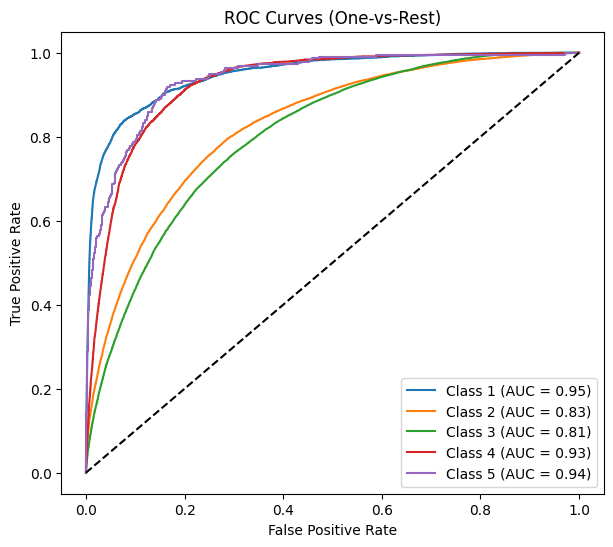

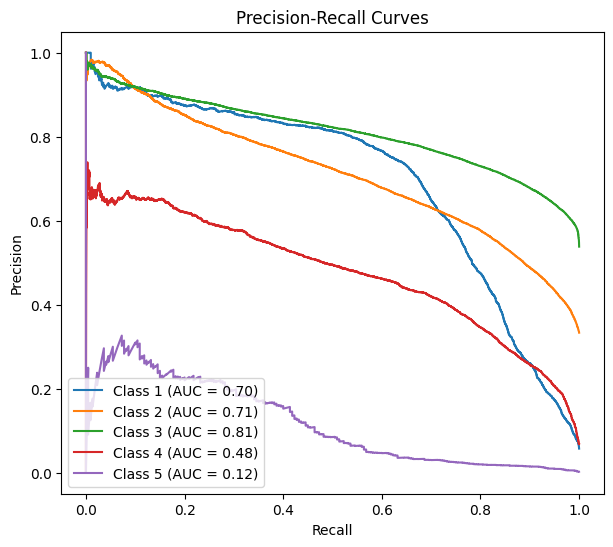

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize labels
y_test_bin = label_binarize(y_test, classes=[1,2,3,4,5])

# Recompute probabilities (if needed)
X_struct_test_scaled = scaler.transform(X_struct_test)
xgb_test_proba = xgb_model.predict_proba(X_struct_test_scaled)

X_text_test_tfidf = vectorizer.transform(X_text_test)
text_test_proba = text_model.predict_proba(X_text_test_tfidf)

X_meta_test = np.hstack([text_test_proba, xgb_test_proba])
y_proba = meta_model.predict_proba(X_meta_test)

# -----------------------------
# ROC CURVES
# -----------------------------
plt.figure(figsize=(7,6))

for i in range(5):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i+1} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.show()

# -----------------------------
# PRECISION-RECALL CURVES
# -----------------------------
plt.figure(figsize=(7,6))

for i in range(5):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"Class {i+1} (AUC = {pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()